<a href="https://colab.research.google.com/github/Kumidhini-925/Skin_cancer_Prediction_efficientnet-B0-/blob/main/Efficientnet_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from matplotlib.image import imread
from keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, concatenate, Dropout
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3,ResNet50, VGG16

In [ ]:
# Create variables to store data paths
train_data_path='/content/drive/MyDrive/isic_dataset/train'
test_data_path='/content/drive/MyDrive/isic_dataset/test'

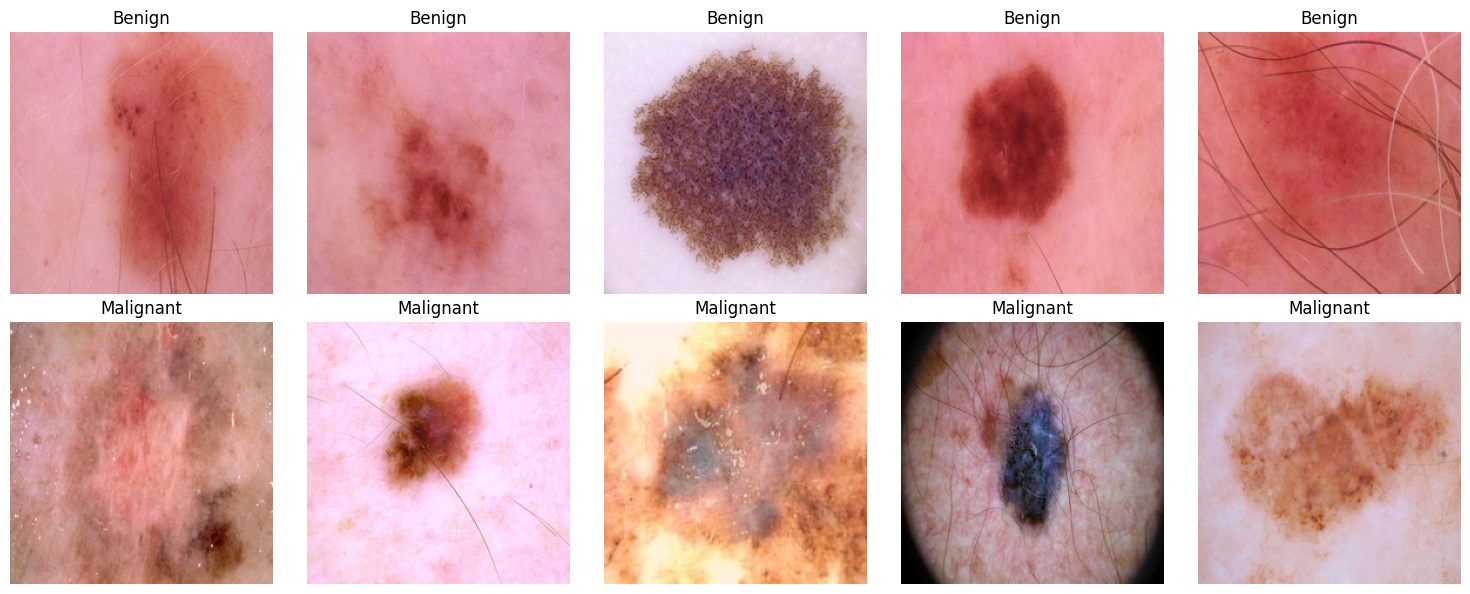

In [ ]:
# Define paths for benign and malignant images
train_data_path = '/content/drive/MyDrive/isic_dataset/train'
benign_path = os.path.join(train_data_path, 'benign')
malignant_path = os.path.join(train_data_path, 'malignant')

# Get lists of image filenames for benign and malignant
benign_images = os.listdir(benign_path)
malignant_images = os.listdir(malignant_path)

# Set up the 2x5 subplot
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Display 5 random benign images in the first row
for i in range(5):
    img_name = random.choice(benign_images)
    img_path = os.path.join(benign_path, img_name)
    img = imread(img_path)
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title('Benign')

# Display 5 random malignant images in the second row
for i in range(5):
    img_name = random.choice(malignant_images)
    img_path = os.path.join(malignant_path, img_name)
    img = imread(img_path)
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title('Malignant')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
def data_preprocessing(output_size):
    # Data augmentation for the training set to help prevent overfitting
    train_datagen = ImageDataGenerator(
        rescale=1./255,            # Normalize pixel values to be between 0 and 1
        zoom_range=0.2,            # Randomly zoom in on images up to 20%
        shear_range=0.2,           # Shear transformation with a 20% intensity
        rotation_range=15,         # Randomly rotate images by up to 15 degrees
        fill_mode='nearest',       # Fill in missing pixels after transformations
        horizontal_flip=True       # Randomly flip images horizontally
    )

    # Data preparation for the test set (no augmentation, only rescaling)
    test_datagen = ImageDataGenerator(
        rescale=1./255             # Normalize pixel values to be between 0 and 1
    )

    # Load and preprocess the training set
    training_set = train_datagen.flow_from_directory(
        train_data_path,           # Path to the training data directory
        target_size=(output_size, output_size),  # Resize all images to the specified size
        batch_size=32,             # Number of images to be yielded from the generator per batch
        class_mode='binary',       # Use binary labels (benign vs malignant)
        shuffle=True               # Shuffle the data to ensure randomness in batches
    )

    # Load and preprocess the test set
    test_set = test_datagen.flow_from_directory(
        test_data_path,            # Path to the test data directory
        target_size=(output_size, output_size),  # Resize all images to the specified size
        batch_size=32,             # Number of images to be yielded from the generator per batch
        class_mode='binary',       # Use binary labels (benign vs malignant)
        shuffle=False              # Do not shuffle test data to maintain order for evaluation
    )

    # Return the processed training and test sets
    return training_set, test_set

In [ ]:
# Emsemble Model Function
def ensemble_model(input_size, base_model):
    # Load the pre-trained EfficientNet model with ImageNet weights, excluding the top classification layers
    efficientnet_model = base_model(weights='imagenet', include_top=False, input_shape=(input_size, input_size, 3))

    # Load the pre-trained VGG16 model with ImageNet weights, excluding the top classification layers
    vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(input_size, input_size, 3))

    # Freeze the layers of EfficientNet to prevent them from being trained
    for layer in efficientnet_model.layers:
        layer.trainable = False

    # Freeze the layers of VGG16 to prevent them from being trained
    for layer in vgg_model.layers:
        layer.trainable = False

    # Define the input layer of the ensemble model
    input_layer = Input(shape=(input_size, input_size, 3))

    # Pass the input through the EfficientNet model
    efficientnet_output = efficientnet_model(input_layer)

    # Pass the input through the VGG16 model
    vgg_output = vgg_model(input_layer)

    # Apply Global Average Pooling to the outputs of both models to reduce each feature map to a single value
    efficientnet_output = GlobalAveragePooling2D()(efficientnet_output)
    vgg_output = GlobalAveragePooling2D()(vgg_output)

    # Concatenate the outputs from both models into a single tensor
    combined_output = concatenate([efficientnet_output, vgg_output])

    # Add a dense layer with 256 units and ReLU activation to process the concatenated features
    x = Dense(1024, activation='relu')(combined_output)
    x = Dense(128, activation='relu')(x)

    # Apply dropout with a rate of 0.5 to prevent overfitting
    x = Dropout(0.5)(x)

    # Add a final dense layer with 1 unit and sigmoid activation for binary classification
    output_layer = Dense(1, activation='sigmoid')(x)

    # Create the ensemble model with the input and output layers defined above
    ensemble_model = Model(inputs=input_layer, outputs=output_layer)

    # Compile the ensemble model with the Adam optimizer and binary cross-entropy loss function
    ensemble_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Print a summary of the model architecture
    ensemble_model.summary()

    return ensemble_model

In [ ]:
# Apply image preprocessing
training_set,test_set = data_preprocessing(output_size=224)

Found 2637 images belonging to 2 classes.
Found 660 images belonging to 2 classes.


In [ ]:
ensemble = ensemble_model(input_size=224,base_model=EfficientNetB0)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_11[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 1792)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1024)      │  1,836,032 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │    131,200 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │        129 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,731,620 (79.08 MB)

 Trainable params: 1,967,361 (7.50 MB)

 Non-trainable params: 18,764,259 (71.58 MB)

In [ ]:
history = ensemble.fit(training_set, validation_data=test_set, epochs=20)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 101s 936ms/step - accuracy: 0.5411 - loss: 0.7680 - val_accuracy: 0.6197 - val_loss: 0.6539
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 573ms/step - accuracy: 0.6829 - loss: 0.6136 - val_accuracy: 0.8167 - val_loss: 0.4468
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 575ms/step - accuracy: 0.7775 - loss: 0.5048 - val_accuracy: 0.7803 - val_loss: 0.4468
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 593ms/step - accuracy: 0.7790 - loss: 0.4765 - val_accuracy: 0.8106 - val_loss: 0.4115
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 578ms/step - accuracy: 0.7946 - loss: 0.4451 - val_accuracy: 0.8333 - val_loss: 0.3842
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 581ms/step - accuracy: 0.8009 - loss: 0.4217 - val_accuracy: 0.8333 - val_loss: 0.3737
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 591ms/step - accuracy: 0.8029 - loss: 0.4374 - val_accuracy: 0.8197 - val_loss: 0.3923
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 588ms/step - accuracy: 0.8083 - loss: 0.4212 - val_acc

In [ ]:
print("Training Accuracy -", round(history.history['accuracy'][-1]*100,2),"%")
print("Validation Accuracy -", round(history.history['val_accuracy'][-1]*100,2),"%")

Training Accuracy - 83.28 %
Validation Accuracy - 84.09 %


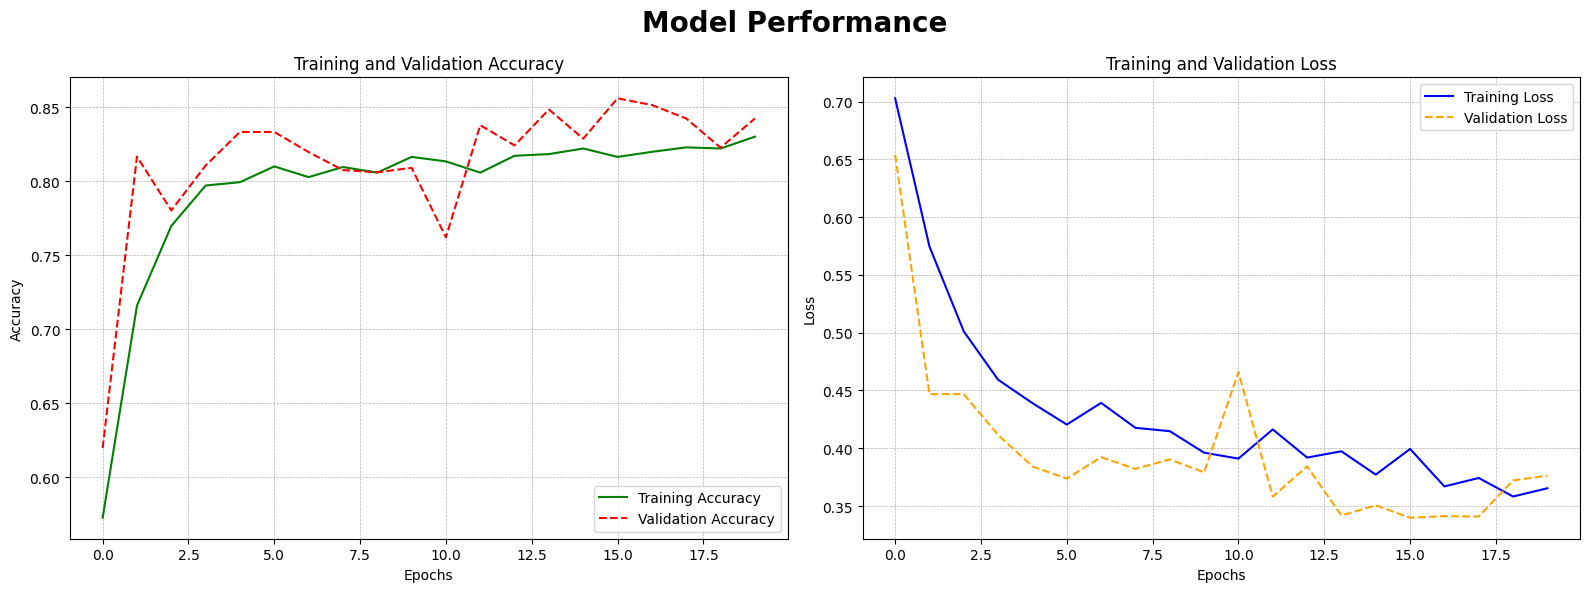

In [ ]:
# Function to plot model performance
def plotting(history):
    # Convert the training history to a DataFrame for easier manipulation and plotting
    plot_data = pd.DataFrame(history.history)

    # Create a figure with 1 row and 2 columns for subplots (Loss and Accuracy)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

    # Define color schemes for plots
    colors = {'loss': 'blue', 'val_loss': 'orange', 'accuracy': 'green', 'val_accuracy': 'red'}

    # Plotting Training and Validation Loss
    axes[1].plot(plot_data.index, plot_data['loss'], label='Training Loss', color=colors['loss'], linestyle='-')
    axes[1].plot(plot_data.index, plot_data['val_loss'], label='Validation Loss', color=colors['val_loss'], linestyle='--')
    axes[1].set_title('Training and Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle='--', linewidth=0.5)

    # Plotting Training and Validation Accuracy
    axes[0].plot(plot_data.index, plot_data['accuracy'], label='Training Accuracy', color=colors['accuracy'], linestyle='-')
    axes[0].plot(plot_data.index, plot_data['val_accuracy'], label='Validation Accuracy', color=colors['val_accuracy'], linestyle='--')
    axes[0].set_title('Training and Validation Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle='--', linewidth=0.5)

    plt.suptitle("Model Performance", size=20, weight='bold')
    plt.tight_layout()
    plt.show()


plotting(history)

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_random_images(model, num_images=5):
    """
    Randomly selects test images and makes predictions using a pre-trained model.

    Args:
    - model (Keras Model): Pre-trained model to use for predictions.
    - num_images (int): Number of random images to predict and display per class. Default is 5.
    """
    # Get list of image file paths for both classes (benign and malignant)
    benign_images = os.listdir(os.path.join(test_data_path, 'benign'))
    malignant_images = os.listdir(os.path.join(test_data_path, 'malignant'))

    # Randomly select images from both classes
    selected_images = []
    actual_labels = []
    for _ in range(num_images):
        benign_img = os.path.join(test_data_path, 'benign', random.choice(benign_images))
        malignant_img = os.path.join(test_data_path, 'malignant', random.choice(malignant_images))
        selected_images.extend([benign_img, malignant_img])
        actual_labels.extend(['Benign', 'Malignant'])

    # Create a plot with 2 rows (first row for benign, second for malignant)
    fig, axes = plt.subplots(2, num_images, figsize=(20, 8))
    fig.suptitle('Random Test Image Predictions', fontsize=18)

    # Loop through selected images, make predictions, and display results
    for i in range(num_images):
        # Display benign images in the first row
        img_path = selected_images[i * 2]
        actual_label = actual_labels[i * 2]
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize pixel values

        prediction = model.predict(img_array)
        predicted_class = 'Malignant' if prediction[0, 0] > 0.5 else 'Benign'
        confidence = prediction[0, 0] * 100 if predicted_class == 'Malignant' else (1 - prediction[0, 0]) * 100

        axes[0, i].imshow(imread(img_path))
        axes[0, i].set_title(f"Actual: {actual_label}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%")
        axes[0, i].axis('off')

        # Display malignant images in the second row
        img_path = selected_images[i * 2 + 1]
        actual_label = actual_labels[i * 2 + 1]
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        prediction = model.predict(img_array)
        predicted_class = 'Malignant' if prediction[0, 0] > 0.5 else 'Benign'
        confidence = prediction[0, 0] * 100 if predicted_class == 'Malignant' else (1 - prediction[0, 0]) * 100

        axes[1, i].imshow(imread(img_path))
        axes[1, i].set_title(f"Actual: {actual_label}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%")
        axes[1, i].axis('off')

    plt.tight_layout()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


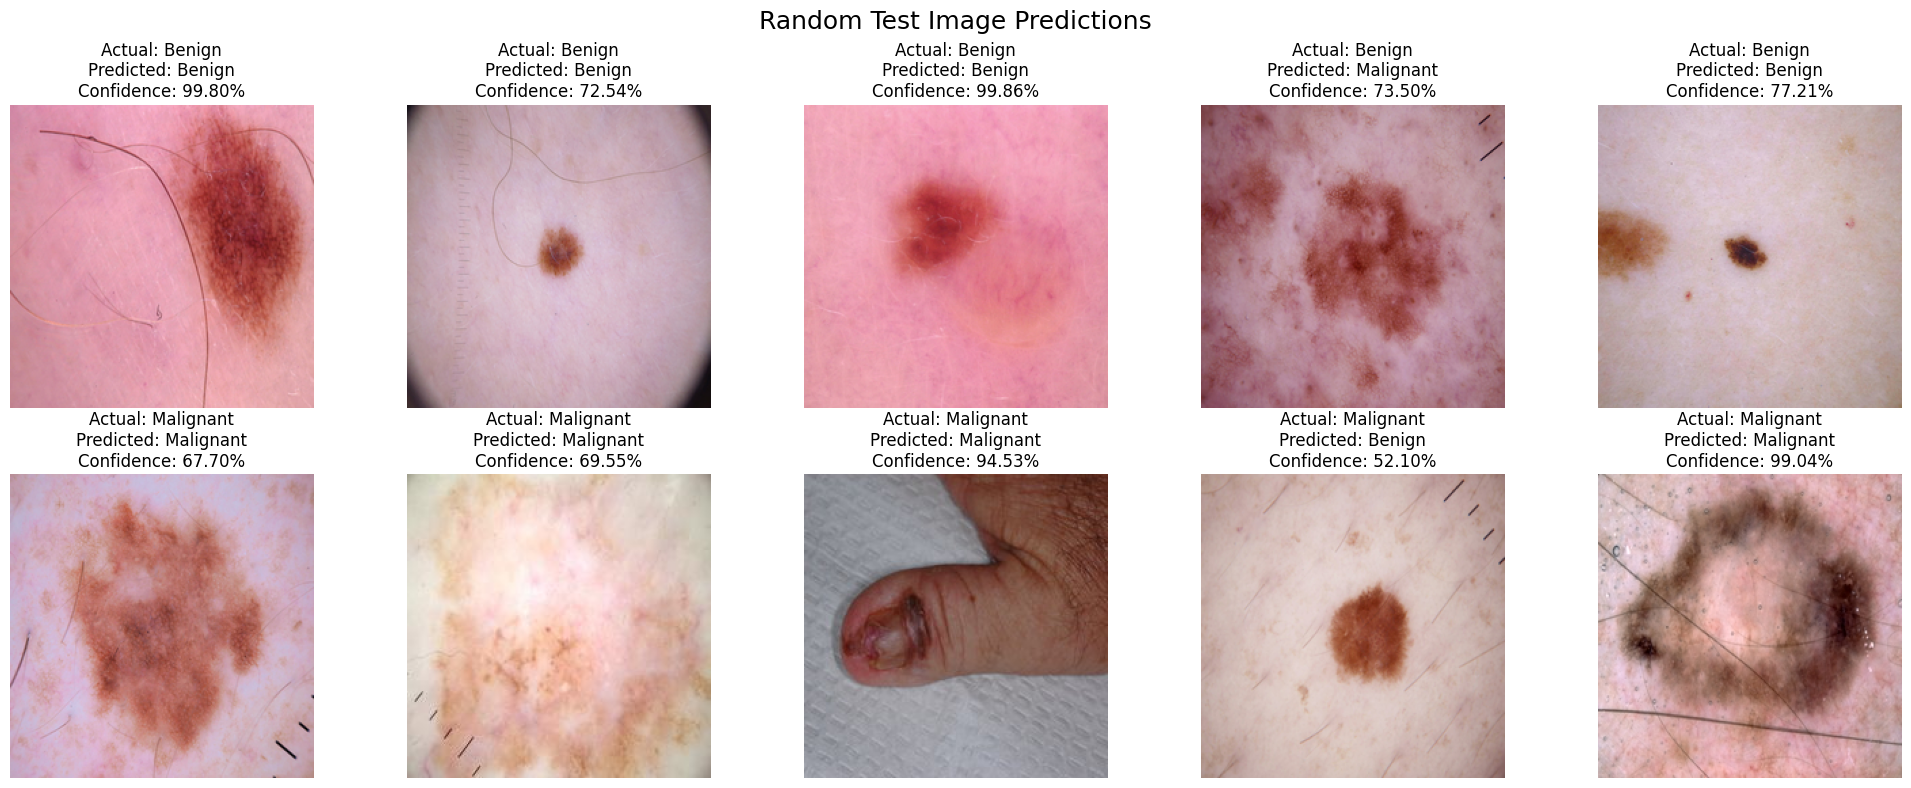

In [ ]:
predict_random_images(ensemble)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Get true labels from the test set generator
y_true = test_set.classes

# Get predicted probabilities from the model
y_pred_proba = ensemble.predict(test_set)

# Convert predicted probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate precision, recall, and f1 score
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 548ms/step
Precision: 0.8551
Recall: 0.7867
F1 Score: 0.8194


21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step


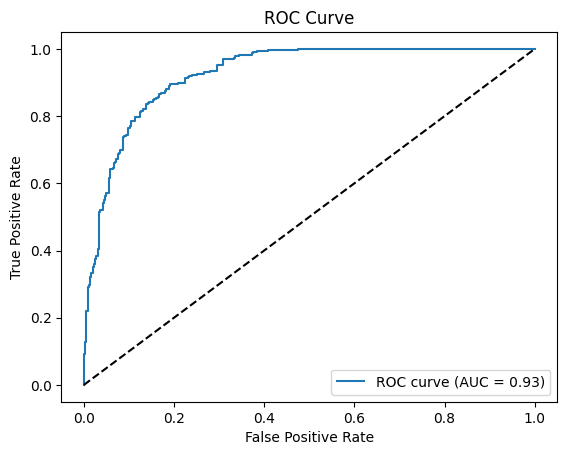

In [ ]:
from sklearn.metrics import roc_curve, auc
y_true = test_set.classes
y_pred_proba = ensemble.predict(test_set)
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step


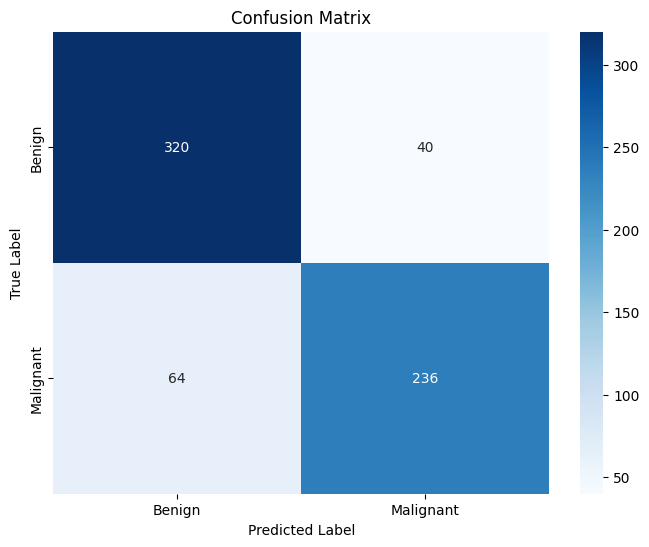


Classification Report:
              precision    recall  f1-score   support

      Benign       0.83      0.89      0.86       360
   Malignant       0.86      0.79      0.82       300

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get the true labels from the test set
test_set.reset()  # Reset the generator to ensure we start from the beginning
y_true = test_set.classes

# Make predictions on the test set
y_pred_prob = ensemble.predict(test_set)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report for more metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))